## Projeto Sprint 8 - Análise de Negócio

### Contexto do Projeto
Trabalhamos no departamento analítico da Y.Afisha e fomos encarregados de otimizar os investimentos em marketing da empresa. Para isso, precisamos entender melhor o perfil dos consumidores e a eficiência dos diferentes canais de aquisição.

### Objetivo
Analisar os dados de janeiro de 2017 a dezembro de 2018 para otimizar os gastos com marketing e maximizar o retorno sobre investimento (ROI).

### Perguntas de Negócio
Este projeto busca responder às seguintes questões estratégicas:
* Qual é o perfil do nosso consumidor?
* Por quais canais de marketing nossos clientes chegam até nós?
* Quando os usuários começam a fazer compras após o primeiro acesso?
* Qual é o retorno sobre investimento (ROI) dos nossos canais de marketing?
* Quanto tempo demora para recuperar o investimento em aquisição de clientes?
* Qual canal oferece o melhor custo-benefício para futuros investimentos?

In [1]:
# Bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np
import warnings
warnings.filterwarnings('ignore')


In [2]:
#Importando os dados de visitas(visits) já com a conversão nas colunas referentes a Start Ts e End Ts (object -> datetime).
# Convertendo a coluna Device para 'category' visto que só temos 2 categorias (Touch e Desktop) para que futuramente possa ser utilizada de forma mais eficiente.
#Além disso, convertendo os nomes das colunas para letras minúsculas para facilitar a manipulação dos dados.
visits = pd.read_csv('visits_log_us.csv', 
                     parse_dates=['Start Ts', 'End Ts'], 
                     dtype={'Device': 'category'})
visits.columns = visits.columns.str.lower()

In [3]:
#importando os dados de pedidos (order) já com a conversão na coluna Buy Ts (object -> datetime).
#Convertendo os nomes das colunas para letras minúsculas para facilitar a manipulação dos dados.
order = pd.read_csv('orders_log_us.csv',
                     parse_dates=['Buy Ts'])
order.columns = order.columns.str.lower()

In [4]:
#Importando os dados de custos(costs) já com a conversão na coluna Dt de (object -> datetime).
#Convertendo os nomes das colunas para letras minúsculas para facilitar a manipulação dos dados.
costs = pd.read_csv('costs_us.csv',
                     parse_dates=['dt'])
costs.columns = costs.columns.str.lower()

## Análisando os DataFrames 

In [5]:
#Analisando os dados de visitas.
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  category      
 1   end ts     359400 non-null  datetime64[ns]
 2   source id  359400 non-null  int64         
 3   start ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: category(1), datetime64[ns](2), int64(1), uint64(1)
memory usage: 11.3 MB


In [6]:
#Observando os dados de visitas(visits).
visits.head()

,device,end ts,source id,start ts,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [7]:
#Analisando os dispositivos utilizados para acessar o site.
device_counts = visits.groupby('device').agg({'uid':'count'})
device_counts.head()

,uid
device,
desktop,262567
touch,96833


In [8]:
#Analisando os dados de pedidos(order).
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [9]:
#Observando os dados de vendas(order).
order.head()

,buy ts,revenue,uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450


In [10]:
#Analisando os dados de custos(costs).
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


In [11]:
costs.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


### Análisando Coortes Comportamentais - Visits

In [12]:
#Criando as colunas de data, semana e mês para a tabela de visitas para facilitar a análise dos dados.
visits['date'] = visits['start ts'].dt.date
visits['week'] = visits['start ts'].dt.isocalendar().week
visits['month'] = visits['start ts'].dt.to_period('M')    

In [13]:
#Usuários únicos por dia, semana e mês.
dau = visits.groupby('date')['uid'].nunique().mean()   
mau = visits.groupby('month')['uid'].nunique().mean()
wau = visits.groupby('week')['uid'].nunique().mean()

#Exibindo os resultados de DAU, MAU e WAU.
print(f'DAU médio: {dau:.2f}')
print(f'MAU médio: {mau:.2f}')
print(f'WAU médio: {wau:.2f}')

DAU médio: 907.99
MAU médio: 23228.42
WAU médio: 5825.29


In [14]:
#Contando quantas pessoas acessam o site cada dia, semana e mês.
unique_users_per_day = visits.groupby(['date','device']).agg({'uid':['nunique','count']}).reset_index()
unique_users_per_week = visits.groupby(['week','device']).agg({'uid':['nunique','count']}).reset_index()
unique_users_per_month = visits.groupby(['month','device']).agg({'uid':['nunique','count']}).reset_index()

#Renomeando as colunas para facilitar a manipulação dos dados.
unique_users_per_day.columns = ['date', 'device', 'unique_users', 'total_visits']
unique_users_per_week.columns = ['week', 'device', 'unique_users', 'total_visits']
unique_users_per_month.columns = ['month', 'device', 'unique_users', 'total_visits']    


#Calculando a taxa de retorno por dia, semana e mês para cada dispositivo.
conversion_rate_per_day = unique_users_per_day.copy()   
conversion_rate_per_day['conversion_rate'] = conversion_rate_per_day['unique_users'] / conversion_rate_per_day['total_visits']  
conversion_rate_per_week = unique_users_per_week.copy()
conversion_rate_per_week['conversion_rate'] = conversion_rate_per_week['unique_users'] / conversion_rate_per_week['total_visits']
conversion_rate_per_month = unique_users_per_month.copy()   
conversion_rate_per_month['conversion_rate'] = conversion_rate_per_month['unique_users'] / conversion_rate_per_month['total_visits']
#Exibindo as taxas de retorno por dia, semana e mês para cada dispositivo.
print("Taxa de retorno por dia e dispositivo:")
print(conversion_rate_per_day.head())
print("\nTaxa de retorno por semana e dispositivo:")
print(conversion_rate_per_week.head())
print("\nTaxa de retorno por mês e dispositivo:")
print(conversion_rate_per_month.head())



Taxa de retorno por dia e dispositivo:
         date   device  unique_users  total_visits  conversion_rate
0  2017-06-01  desktop           455           501         0.908184
1  2017-06-01    touch           153           163         0.938650
2  2017-06-02  desktop           458           498         0.919679
3  2017-06-02    touch           152           160         0.950000
4  2017-06-03  desktop           307           329         0.933131

Taxa de retorno por semana e dispositivo:
   week   device  unique_users  total_visits  conversion_rate
0     1  desktop          4250          4997         0.850510
1     1    touch          2716          3060         0.887582
2     2  desktop          4875          5771         0.844741
3     2    touch          1883          2100         0.896667
4     3  desktop          5128          6224         0.823907

Taxa de retorno por mês e dispositivo:
     month   device  unique_users  total_visits  conversion_rate
0  2017-06  desktop          9761

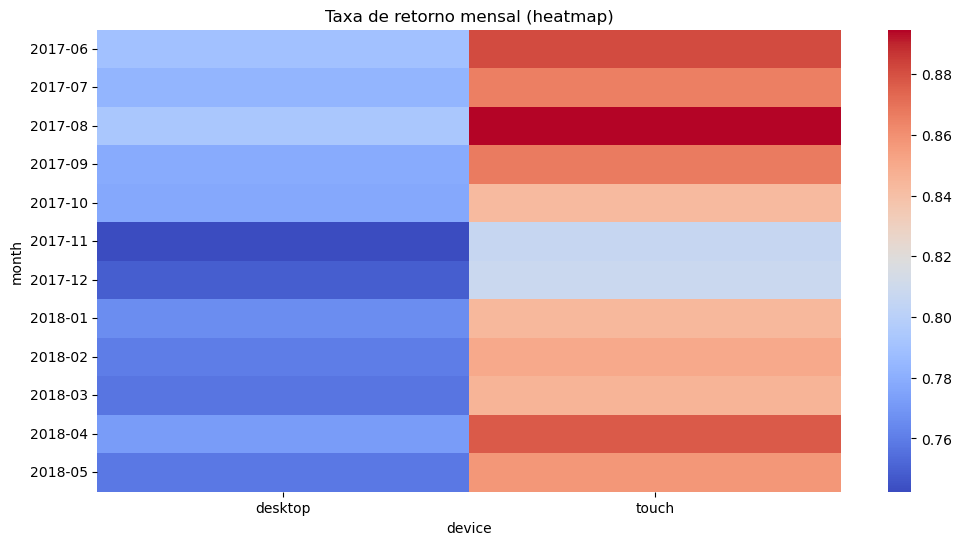

In [39]:
#Visualizando a taxa de retorno por mês e dispositivo.
pivot = conversion_rate_per_month.pivot_table(
    index='month',
    columns='device',
    values='conversion_rate'
)
plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='coolwarm')
plt.title('Taxa de retorno mensal (heatmap)')
plt.show()

In [22]:
#Calculando o tempo médio gasto no site por cada dispositivo.
visits['duration'] = (visits['end ts'] - visits['start ts']).dt.total_seconds() / 60  # Convertendo a duração para minutos
average_duration_per_device = visits.groupby('device')['duration'].mean()
average_duration_per_device.columns = ['device', 'average_duration_minutes']
print("Tempo médio gasto no site por cada dispositivo (em minutos):")
print(average_duration_per_device.round(2))  

Tempo médio gasto no site por cada dispositivo (em minutos):
device
desktop    11.72
touch       7.99
Name: duration, dtype: float64


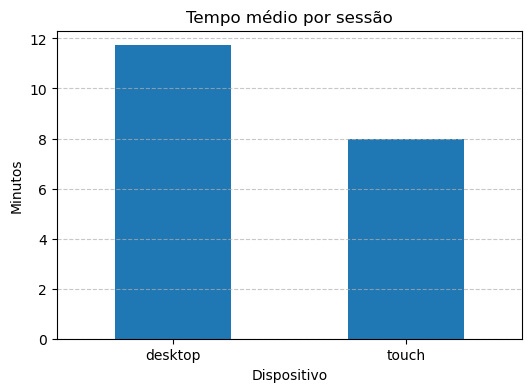

In [ ]:
#Visualizando o tempo médio gasto no site por cada dispositivo.
average_duration_per_device.plot(kind='bar', figsize=(6,4))
plt.title('Tempo médio por sessão')
plt.ylabel('Minutos')
plt.xlabel('Dispositivo')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [17]:
#Frequencia que os usuarios voltano ao site.
user_visit_counts = visits.groupby('uid').size().reset_index(name='visit_count')
print("Frequência de visitas por usuário:")
print(user_visit_counts.head())


Frequência de visitas por usuário:
               uid  visit_count
0   11863502262781            1
1   49537067089222            1
2  297729379853735            1
3  313578113262317            3
4  325320750514679            2


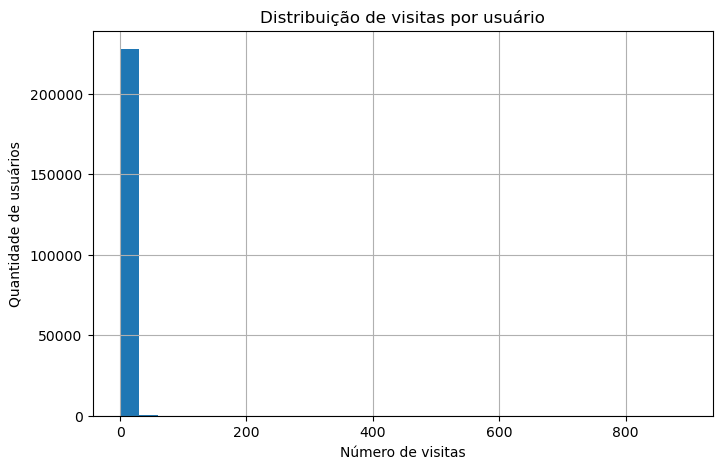

In [ ]:
#Visualizando a distribuição de visitas por usuário.
user_visit_counts['visit_count'].hist(figsize=(8,5), bins=30)

plt.title('Distribuição de visitas por usuário')
plt.xlabel('Número de visitas')
plt.ylabel('Quantidade de usuários')
plt.show()